In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df=pd.read_csv("/content/sample_data/netflix_titles.csv")

In [7]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [8]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


<Axes: >

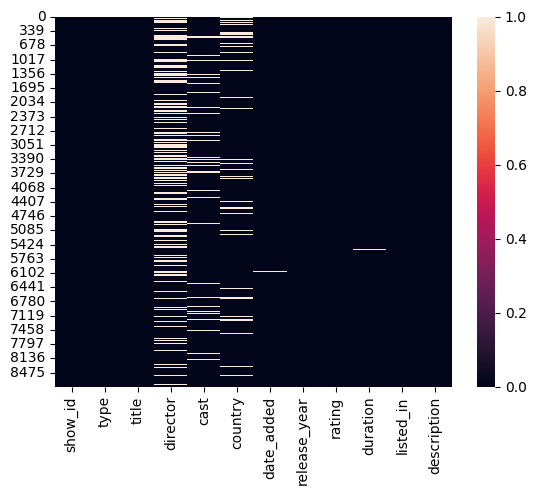

In [10]:
sns.heatmap(df.isnull())

In [11]:
df[['cast','director','country']]=df[['cast','director','country']].fillna("unknown")


<Axes: >

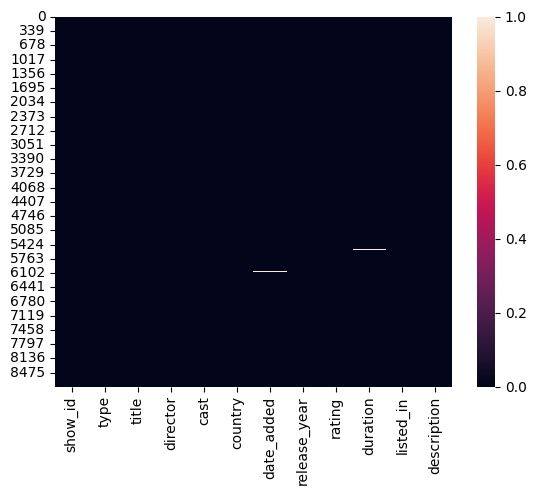

In [12]:
sns.heatmap(df.isnull())

In [13]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,10
release_year,0
rating,4
duration,3


In [14]:
duplicate=df.duplicated().sum()
print("No. of dublicate rows are :",duplicate)

No. of dublicate rows are : 0


In [15]:
df.dropna(subset=['date_added','rating','duration'],inplace =True)
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,unknown,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,20-Nov-19,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,unknown,unknown,unknown,1-Jul-19,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,1-Nov-19,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,11-Jan-20,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [16]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [17]:
tv_show=df['type']=='TV Show'
print(tv_show.sum())

2664


In [18]:
movie=df['type']=='Movie'
print(movie.sum())

6126


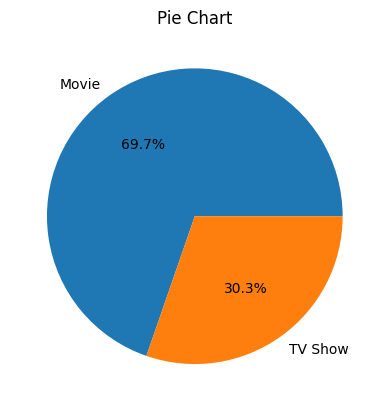

In [19]:
type=df['type'].value_counts()

plt.pie(type,labels=type.index,autopct="%1.1f%%")
plt.title('Pie Chart')
plt.show()

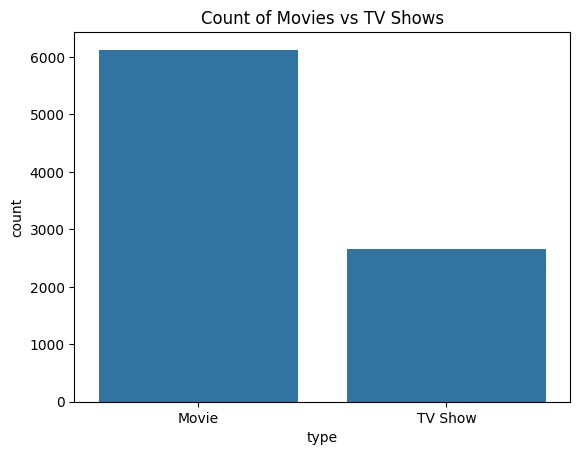

In [20]:
sns.countplot(data=df,x="type")
plt.title('Count of Movies vs TV Shows')
plt.show()

In [21]:
con=df['country'].value_counts()
con

,count
country,
United States,2809
India,972
unknown,829
United Kingdom,418
Japan,243
...,...
"Germany, Canada, United States",1
"Denmark, United Kingdom, South Africa, Sweden, Belgium",1
"Serbia, South Korea, Slovenia",1


In [22]:
con=df['country'].str.split(", ").explode().value_counts()
ind=con.head(10)

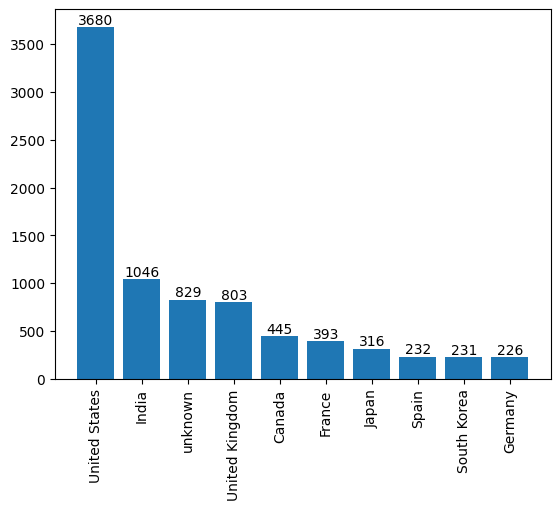

In [23]:
fig, ax = plt.subplots()
bar=ax.bar(ind.index,ind.values)
ax.bar_label(bar)
plt.xticks(rotation=90)
plt.show()

In [24]:
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,unknown,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",unknown,24-Sep-21,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",unknown,24-Sep-21,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",24-Sep-21,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,24-Sep-21,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,24-Sep-21,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [25]:
movie=df[df['type']=='Movie']
movie

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",unknown,24-Sep-21,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",24-Sep-21,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,24-Sep-21,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",23-Sep-21,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...
...,...,...,...,...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan",9-Mar-16,2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,20-Nov-19,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,1-Nov-19,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,11-Jan-20,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [26]:
df_clean=df.copy()


In [27]:
df_movie=df_clean[df_clean['type']=='Movie']
df_movie.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",unknown,24-Sep-21,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...


In [28]:
df_movie['duration_num']=df_movie['duration'].str.extract('(\d+)').astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1292/408295264.py:1: SyntaxWarning: invalid escape sequence '\d'
  df_movie['duration_num']=df_movie['duration'].str.extract('(\d+)').astype(float)
/tmp/ipykernel_1292/408295264.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_movie['duration_num']=df_movie['duration'].str.extract('(\d+)').astype(float)


In [29]:

df_clean['duration_numeric']=df_clean['duration'].str.extract('(\d+)').astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1292/2558616473.py:1: SyntaxWarning: invalid escape sequence '\d'
  df_clean['duration_numeric']=df_clean['duration'].str.extract('(\d+)').astype(float)


In [30]:
avg_movie_duration=df_clean[df_clean['type']=='Movie']['duration_numeric'].mean()
avg_movie_duration

np.float64(99.58488410055502)

In [31]:
min=df_clean[df_clean['type']=='Movie']['duration_numeric'].min()
min

3.0

In [32]:
max=df_clean[df_clean['type']=='Movie']['duration_numeric'].max()
max

312.0

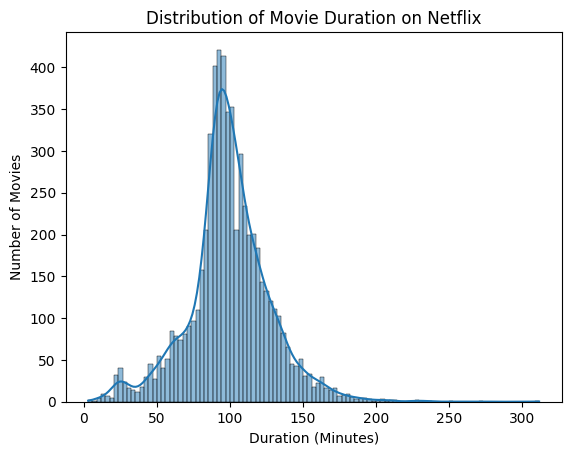

In [33]:
sns.histplot(df_movie['duration_num'].dropna(),kde=True)

plt.title('Distribution of Movie Duration on Netflix')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Number of Movies')
plt.show()

In [34]:
df_clean["duration_numeric"].value_counts()

,count
duration_numeric,
1.0,1791
2.0,421
3.0,199
90.0,152
97.0,146
...,...
228.0,1
18.0,1
205.0,1


In [35]:
df_movie['duration_num'].value_counts()

,count
duration_num,
90.0,152
97.0,146
94.0,146
93.0,146
91.0,144
...,...
228.0,1
18.0,1
205.0,1


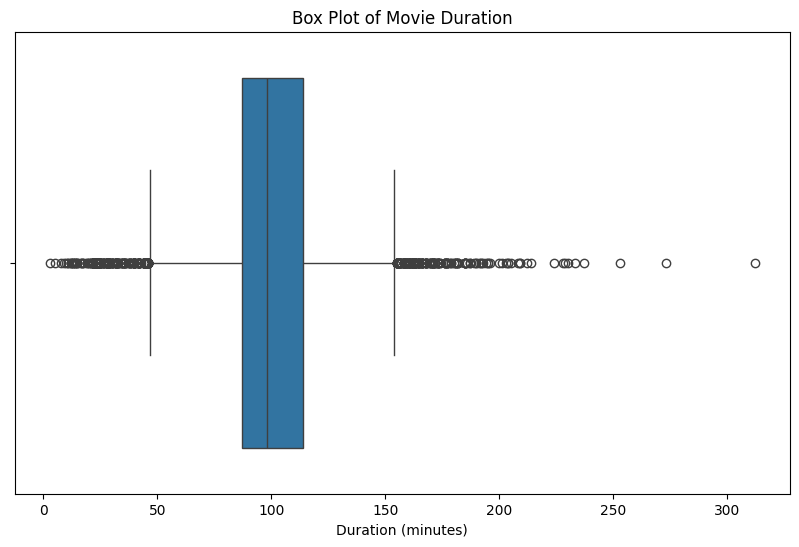

In [36]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_movie['duration_num'])
plt.title('Box Plot of Movie Duration')
plt.xlabel('Duration (minutes)')
plt.show()


In [37]:
from scipy import stats
import numpy as np

z_scores = np.abs(stats.zscore(df_movie['duration_num']))

# in stastics 3 std deviation is considerd rare event
# std deviation = 3 means it lies in 99.7 percentile
z_outliers = df_movie[z_scores > 3]
print(f"Z-Score Outliers found: {len(z_outliers)}")

Z-Score Outliers found: 56


In [38]:
df_movie['release_decade'] = (df_movie['release_year'] // 10) * 10

/tmp/ipykernel_1292/929542200.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_movie['release_decade'] = (df_movie['release_year'] // 10) * 10


In [39]:
df_movie['release_decade'].value_counts()

,count
release_decade,
2010,4179
2020,794
2000,677
1990,241
1980,122
1970,66
1960,23
1940,13
1950,11


In [40]:
df_movie['release_decade'] = df_movie['release_decade'].astype(str) + 's'

/tmp/ipykernel_1292/4126254471.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_movie['release_decade'] = df_movie['release_decade'].astype(str) + 's'


In [41]:
print(df_movie[['title', 'release_year', 'release_decade']].head())

                               title  release_year release_decade
0               Dick Johnson Is Dead          2020          2020s
6   My Little Pony: A New Generation          2021          2020s
7                            Sankofa          1993          1990s
9                       The Starling          2021          2020s
12                      Je Suis Karl          2021          2020s


In [42]:
current_year = 2026
df_movie['content_age'] = current_year - df_movie['release_year']

/tmp/ipykernel_1292/260221207.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_movie['content_age'] = current_year - df_movie['release_year']


In [43]:
bins = [0, 89, 120, float('inf')]
labels = ['Short', 'Medium', 'Long']

df_movie['duration_category'] = pd.cut(
    df_movie['duration_num'],
    bins=bins,
    labels=labels
)

print(df_movie[['title', 'duration_num', 'duration_category']].head())

                               title  duration_num duration_category
0               Dick Johnson Is Dead          90.0            Medium
6   My Little Pony: A New Generation          91.0            Medium
7                            Sankofa         125.0              Long
9                       The Starling         104.0            Medium
12                      Je Suis Karl         127.0              Long


/tmp/ipykernel_1292/2706261620.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_movie['duration_category'] = pd.cut(


In [44]:
print(df_movie[df_movie['duration_category']=='Long'])

     show_id   type                  title                 director  \
7         s8  Movie                Sankofa             Haile Gerima   
12       s13  Movie           Je Suis Karl      Christian Schwochow   
22       s23  Movie        Avvai Shanmughi           K.S. Ravikumar   
24       s25  Movie                  Jeans               S. Shankar   
26       s27  Movie         Minsara Kanavu              Rajiv Menon   
...      ...    ...                    ...                      ...   
8772   s8773  Movie  Yamla Pagla Deewana 2           Sangeeth Sivan   
8773   s8774  Movie    Yanda Kartavya Aahe             Kedar Shinde   
8788   s8789  Movie           You Carry Me               Ivona Juka   
8798   s8799  Movie               Zed Plus  Chandra Prakash Dwivedi   
8802   s8803  Movie                 Zodiac            David Fincher   

                                                   cast  \
7     Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...   
12    Luna Wedler, Jannis Nie

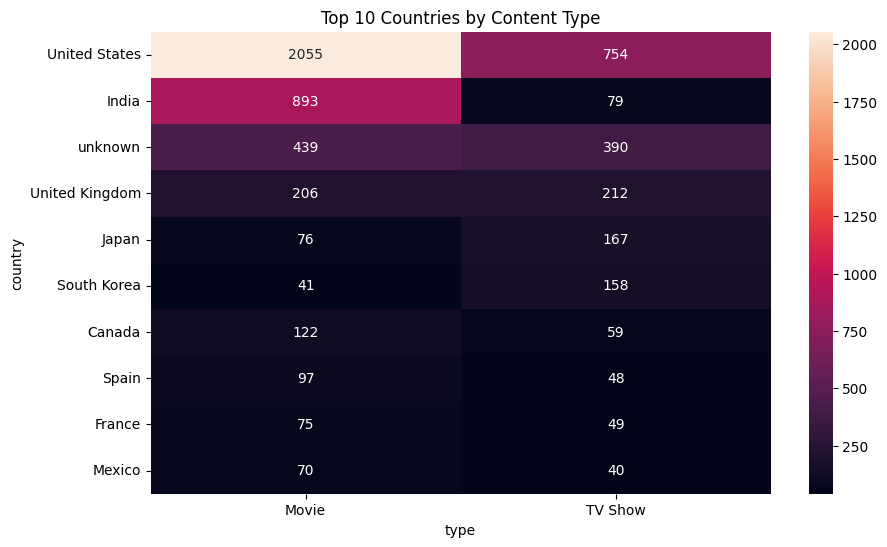

In [49]:
country_ct = pd.crosstab(df['country'], df['type'])

top_countries = country_ct.sum(axis=1).nlargest(10).index
subset = country_ct.loc[top_countries]

plt.figure(figsize=(10, 6))
sns.heatmap(subset, annot=True, fmt="d" )
plt.title('Top 10 Countries by Content Type')
plt.show()

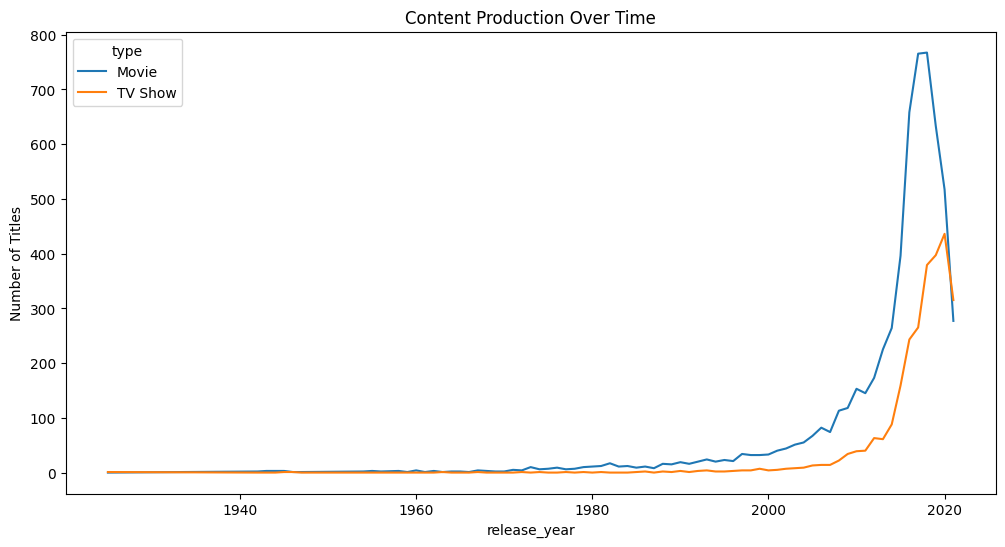

In [50]:
year_type = df.groupby(['release_year', 'type']).size().unstack(fill_value=0)

year_type.plot(kind='line', figsize=(12, 6))
plt.title('Content Production Over Time')
plt.ylabel('Number of Titles')
plt.show()

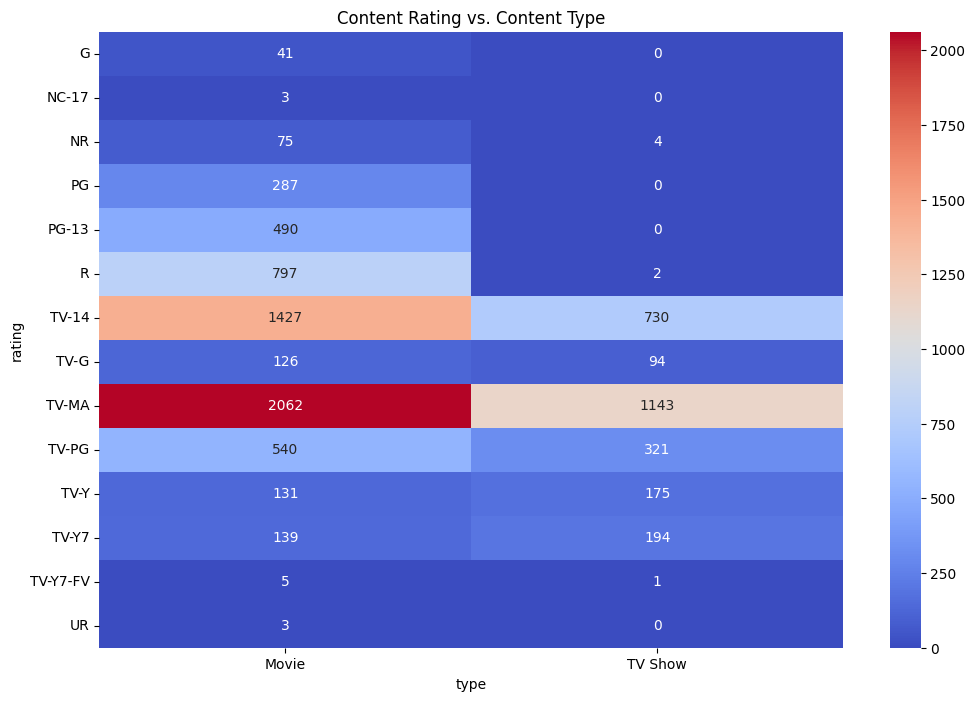

In [51]:
rating_ct = pd.crosstab(df['rating'], df['type'])

plt.figure(figsize=(12, 8))
sns.heatmap(rating_ct, annot=True, fmt="d", cmap="coolwarm")
plt.title('Content Rating vs. Content Type')
plt.show()